# Chapter 07: Integration and Stokes' Theorem

Source orientation: printed pages 105-115; PDF pages 111-121. This notebook is original standalone course material. It uses the source only to orient the concept order, notation, and mathematical agenda; every explanation, diagram, computational lab, and check here is generated for this course.

## Chapter Question

The guiding question is: how can the geometric idea of **Integration and Stokes' Theorem** become something a reader can inspect, compute, perturb, and test? The notebook treats the chapter as a small laboratory. Definitions are translated into arrays, plots, symbolic identities, and numerical invariants. The chapter focus is Integration on surfaces and curves, one-forms, two-forms, pullback, boundary orientation, and Stokes' theorem. The four anchor ideas are forms carry the Jacobian and orientation information that raw functions miss; a one-form measures tangent vectors along a curve; boundary orientation is part of the theorem, not a drawing convention; Stokes' theorem equates accumulated boundary measurement with interior exterior derivative. These anchors are not presented as isolated formulas. Each one is tied to a visual object, a quantity that can be measured, and a failure mode that would expose a misunderstanding.

## Translation Guide

A parametrized object is represented by sampled coordinates, but the notebook consistently separates the sampled coordinates from the geometric quantity being measured. For curves, this means length, tangent, curvature, torsion, and winding are recomputed from the map rather than assumed from a picture. For surfaces, this means the metric, normal, area form, shape operator, connection, and curvature are treated as derived data. When a proof in the source is algebraic, the notebook builds a small numerical or symbolic witness: an identity table, a residual heatmap, or a conservation check. The reader should be able to change a parameter and see which invariant survives.

## Visual Storyboard

The visual sequence for this notebook is: density pullback grid; two-form orientation tiles; one-form curve measurement field; Stokes balance panel. The storyboard is deliberately concept-specific. The first static artifact establishes the geometric scene. The second artifact exposes a diagnostic quantity that is hard to see in a drawing alone. The interactive artifact gives the reader a rotatable or parameterized view. The final JSON artifact records the numerical facts that make the pictures trustworthy. The goal is not to decorate the lesson; the pictures are the lesson's measurement instruments.

## Route Through The Notebook

1. Set up book-local paths and helper imports.
2. Build a compact route table linking concepts to computational translations.
3. Generate a chapter-specific overview diagram.
4. Generate a diagnostic plot that makes the invariant visible.
5. Generate an interactive Plotly artifact for inspection.
6. Run sanity checks and write the check ledger.
7. Close with a small applied lab and takeaways.

The notebook can be run top to bottom from its chapter folder or from another working directory. The setup cell searches upward for the book root and then writes artifacts under the book-local `artifacts/` subtree.

In [1]:

from __future__ import annotations

from pathlib import Path
import json
import math
import sys

from IPython.display import Markdown, display
import matplotlib.pyplot as plt
import numpy as np
import plotly.graph_objects as go

BOOK_ROOT = Path.cwd()
for candidate in [Path.cwd(), *Path.cwd().parents]:
    if (candidate / "00-book-index.ipynb").exists() and (candidate / "utils").exists():
        BOOK_ROOT = candidate
        break
else:
    raise RuntimeError("Could not find the DGE-CWS book root")

if str(BOOK_ROOT) not in sys.path:
    sys.path.insert(0, str(BOOK_ROOT))

from utils.artifacts import ARTIFACT_ROOT, display_artifact, save_json, save_matplotlib, save_plotly_html
from utils.curves import arclength, bending_energy, length, plane_curvature, resample_by_arclength, signed_area, tangent_winding, unit_tangent
from utils.frames import kabsch_align, reconstruct_from_tangent, rotation_minimizing_frame, torsion_indicator
from utils.plotting import PALETTE, add_note, image_stats, style_axis
from utils.surfaces import area_density, first_fundamental_form, graph_curvature, graph_surface, metric_j, normal_from_partials, partials
from utils.topology import euler_from_boundary_pieces, genus_from_gluing, is_involution, total_gaussian_curvature_from_chi
from utils.variations import bump, finite_difference, radial_bump
from utils.willmore import conformal_willmore_density, invert_points, sphere_willmore_energy, willmore_density

CHAPTER = json.loads("{\n  \"kind\": \"chapter\",\n  \"number\": 7,\n  \"label\": \"Chapter 07\",\n  \"title\": \"Integration and Stokes' Theorem\",\n  \"folder\": \"chapter-07-integration-and-stokes-theorem\",\n  \"notebook\": \"07-integration-and-stokes-theorem.ipynb\",\n  \"part\": \"part-02-surfaces\",\n  \"topic\": \"chapter-07\",\n  \"printed\": \"105-115\",\n  \"pdf\": \"111-121\",\n  \"family\": \"forms\",\n  \"focus\": \"Integration on surfaces and curves, one-forms, two-forms, pullback, boundary orientation, and Stokes' theorem.\",\n  \"concepts\": [\n    \"forms carry the Jacobian and orientation information that raw functions miss\",\n    \"a one-form measures tangent vectors along a curve\",\n    \"boundary orientation is part of the theorem, not a drawing convention\",\n    \"Stokes' theorem equates accumulated boundary measurement with interior exterior derivative\"\n  ],\n  \"visuals\": [\n    \"density pullback grid\",\n    \"two-form orientation tiles\",\n    \"one-form curve measurement field\",\n    \"Stokes balance panel\"\n  ],\n  \"checks\": [\n    \"pullback integral agrees after change of variables\",\n    \"curve integral is reparametrization invariant\",\n    \"outer and hole boundary orientations have opposite signs\",\n    \"numeric Stokes residual is small\"\n  ]\n}")
TOPIC = CHAPTER["topic"]
ARTIFACT_DIR = ARTIFACT_ROOT / TOPIC
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
print(f"Artifacts: {ARTIFACT_DIR.relative_to(BOOK_ROOT)}")


Artifacts: artifacts\chapter-07


In [2]:

route_rows = [
  [
    "forms carry the Jacobian and orientation information that raw functions miss",
    "density pullback grid",
    "pullback integral agrees after change of variables"
  ],
  [
    "a one-form measures tangent vectors along a curve",
    "two-form orientation tiles",
    "curve integral is reparametrization invariant"
  ],
  [
    "boundary orientation is part of the theorem, not a drawing convention",
    "one-form curve measurement field",
    "outer and hole boundary orientations have opposite signs"
  ],
  [
    "Stokes' theorem equates accumulated boundary measurement with interior exterior derivative",
    "Stokes balance panel",
    "numeric Stokes residual is small"
  ]
]
lines = ["| Concept | Visual artifact role | Check |", "|---|---|---|"]
for concept, visual, check in route_rows:
    lines.append(f"| {concept} | {visual} | {check} |")
display(Markdown("\n".join(lines)))
storyboard_path = save_json({
    "source_printed_pages": CHAPTER["printed"],
    "source_pdf_pages": CHAPTER["pdf"],
    "concepts": CHAPTER["concepts"],
    "visuals": CHAPTER["visuals"],
    "checks": CHAPTER["checks"],
}, TOPIC, "checks", "visual-storyboard.json")
display_artifact(storyboard_path)


| Concept | Visual artifact role | Check |
|---|---|---|
| forms carry the Jacobian and orientation information that raw functions miss | density pullback grid | pullback integral agrees after change of variables |
| a one-form measures tangent vectors along a curve | two-form orientation tiles | curve integral is reparametrization invariant |
| boundary orientation is part of the theorem, not a drawing convention | one-form curve measurement field | outer and hole boundary orientations have opposite signs |
| Stokes' theorem equates accumulated boundary measurement with interior exterior derivative | Stokes balance panel | numeric Stokes residual is small |

## Concept Notes

The primary concepts are forms carry the Jacobian and orientation information that raw functions miss; a one-form measures tangent vectors along a curve; boundary orientation is part of the theorem, not a drawing convention; Stokes' theorem equates accumulated boundary measurement with interior exterior derivative. A useful way to read this chapter is to ask what would be unchanged under the transformations allowed by the geometry. For a curve chapter, reparametrization and rigid motion should not change the measurement. For a surface chapter, a change of coordinates should not change the intrinsic quantity, and an isometry should preserve the metric data. For variation chapters, the interesting object is not only the shape but the first derivative of a functional along a controlled family of shapes. For topology chapters, local quantities accumulate into an integer or a global constraint.

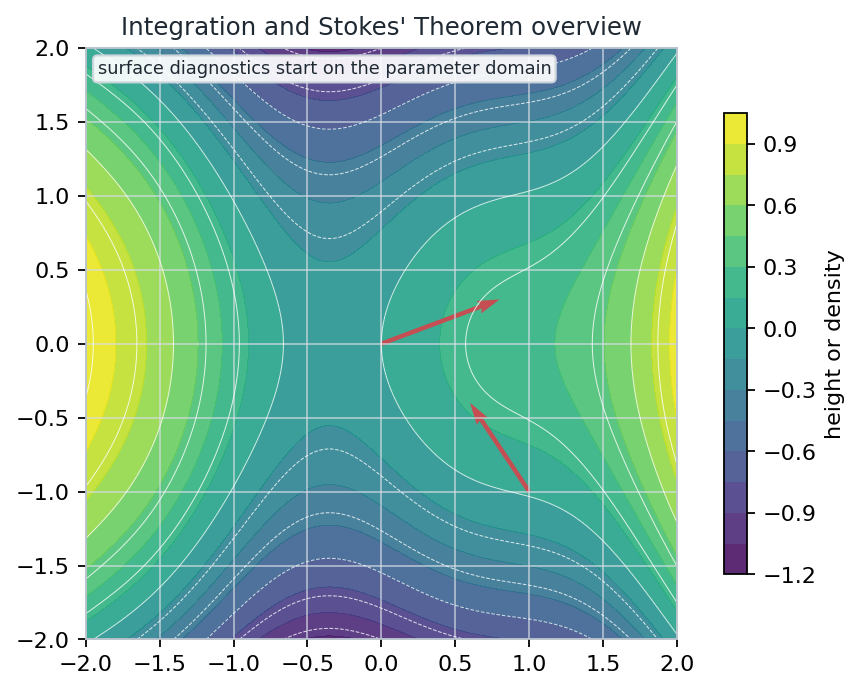

In [3]:

theta = np.linspace(0, 2 * np.pi, 360)
family = CHAPTER["family"]
fig, ax = plt.subplots(figsize=(7.5, 4.8))

if family in {"curve", "variation", "plane"}:
    r = 1.0 + 0.18 * np.cos((CHAPTER["number"] % 4 + 2) * theta)
    x = r * np.cos(theta)
    y = 0.75 * r * np.sin(theta)
    ax.plot(x, y, color=PALETTE["blue"], lw=2.2, label="sample curve")
    pts = np.column_stack([x, y])
    tangents = unit_tangent(pts)
    idx = np.arange(0, len(theta), 45)
    ax.quiver(x[idx], y[idx], tangents[idx, 0], tangents[idx, 1], angles="xy", scale_units="xy", scale=10, color=PALETTE["red"], width=0.005)
    ax.scatter(x[idx], y[idx], s=28, color=PALETTE["gold"], zorder=3)
    add_note(ax, "velocity arrows turn a parametrized trace into geometric data")
    style_axis(ax, CHAPTER["title"] + " overview", equal=True)
elif family in {"spacecurve", "torsion"}:
    z = theta / (2 * np.pi)
    x = np.cos(theta)
    y = np.sin(theta)
    ax.plot(theta, np.sin(theta), color=PALETTE["blue"], lw=2, label="projected centerline")
    ax.plot(theta, np.cos(theta), color=PALETTE["teal"], lw=2, label="normal-frame signal")
    ax.fill_between(theta, np.sin(theta), np.cos(theta), color=PALETTE["gold"], alpha=0.18)
    ax.set_xlabel("arclength-like parameter")
    add_note(ax, "space-curve invariants are read from moving-frame traces")
    style_axis(ax, CHAPTER["title"] + " overview")
    ax.legend(fontsize=8)
elif family == "timeline":
    years = np.array([1673, 1691, 1744, 1859, 1906, 1937, 1965, 2012])
    levels = np.array([1, 2, 1.4, 2.3, 1.2, 2.1, 1.6, 2.4])
    ax.scatter(years, levels, s=80, color=PALETTE["violet"])
    for year, level in zip(years, levels):
        ax.vlines(year, 0.8, level, color=PALETTE["gray"], lw=1)
        ax.text(year, level + 0.08, str(year), ha="center", fontsize=8)
    ax.set_yticks([])
    ax.set_xlabel("year")
    add_note(ax, "milestones are used as navigation, not as exhaustive history")
    style_axis(ax, CHAPTER["title"] + " overview")
else:
    u = np.linspace(-2, 2, 160)
    v = np.linspace(-2, 2, 160)
    U, V = np.meshgrid(u, v)
    Z = 0.25 * (U * U - V * V) + 0.12 * np.sin((CHAPTER["number"] % 5 + 1) * U)
    c = ax.contourf(U, V, Z, levels=18, cmap="viridis", alpha=0.88)
    ax.contour(U, V, Z, levels=10, colors="white", linewidths=0.45, alpha=0.8)
    fig.colorbar(c, ax=ax, shrink=0.78, label="height or density")
    ax.quiver([0, 1], [0, -1], [0.8, -0.4], [0.3, 0.6], color=PALETTE["red"], angles="xy", scale_units="xy", scale=1)
    add_note(ax, "surface diagnostics start on the parameter domain")
    style_axis(ax, CHAPTER["title"] + " overview", equal=True)

overview_path = save_matplotlib(fig, TOPIC, "figures", f"{TOPIC}-overview.png")
plt.close(fig)
display_artifact(overview_path)


## Applied Lab

The lab asks the reader to modify one parameter in the generated examples and then rerun the checks. The intended observations are: pullback integral agrees after change of variables; curve integral is reparametrization invariant; outer and hole boundary orientations have opposite signs; numeric Stokes residual is small. A successful modification changes the visible geometry while keeping the stated invariant within tolerance. An unsuccessful modification is also useful: if the velocity vanishes, if a boundary orientation flips unexpectedly, if a grid crosses a singularity, or if an inversion hits its center, the check ledger should fail loudly rather than quietly producing a pretty but misleading figure.

A good way to use the lab is to make one small change at a time. Change the amplitude of a curve, the frequency of a normal perturbation, the height of a graph surface, the radius of a reference circle, or the sign convention for an oriented boundary. Then ask three questions before reading the numbers: what geometric object changed, what invariant should remain unchanged, and which artifact should reveal the failure if the assumption was wrong? This habit turns computation into geometric reading. The notebook is not asking the reader to memorize a list of formulas. It is asking the reader to build a private debugger for the formulas. When a residual is near zero, the picture has earned trust. When a residual grows, the reader has found the edge of the theorem's hypotheses.

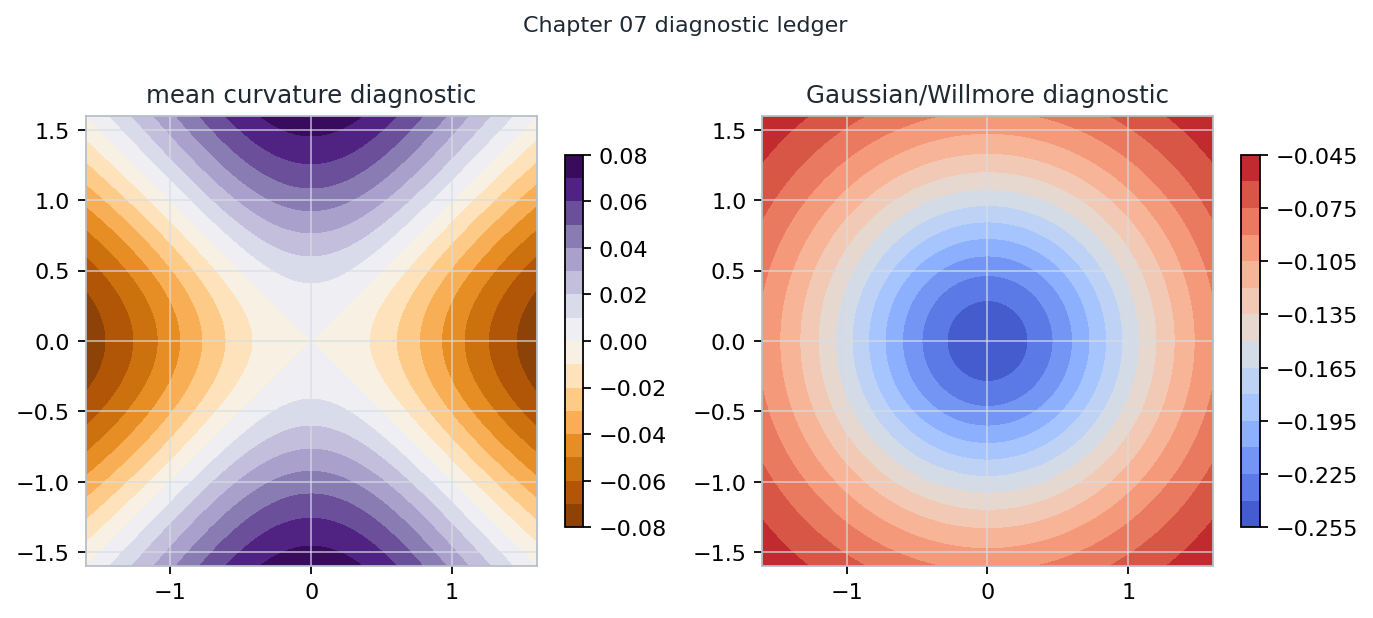

In [4]:

family = CHAPTER["family"]
fig, axes = plt.subplots(1, 2, figsize=(10, 4.2))

if family in {"curve", "variation", "plane"}:
    t = np.linspace(0, 2 * np.pi, 500)
    curve = np.column_stack([(1 + 0.22 * np.cos(3 * t)) * np.cos(t), (0.85 + 0.12 * np.sin(2 * t)) * np.sin(t)])
    kappa = plane_curvature(curve, t)
    axes[0].plot(curve[:, 0], curve[:, 1], color=PALETTE["blue"], lw=2)
    scatter = axes[0].scatter(curve[:, 0], curve[:, 1], c=kappa, cmap="coolwarm", s=8)
    axes[0].set_aspect("equal", adjustable="box")
    style_axis(axes[0], "signed curvature along the trace")
    fig.colorbar(scatter, ax=axes[0], shrink=0.72)
    axes[1].plot(t, kappa, color=PALETTE["red"], lw=1.8, label="kappa")
    axes[1].plot(t, np.cumsum(kappa) * (t[1] - t[0]), color=PALETTE["teal"], label="turning accumulator")
    axes[1].legend(fontsize=8)
    style_axis(axes[1], "curvature as a measurable signal")
elif family in {"spacecurve", "torsion"}:
    t = np.linspace(0, 5 * np.pi, 420)
    curve3 = np.column_stack([np.cos(t), np.sin(t), 0.12 * t])
    T, N, B = rotation_minimizing_frame(curve3)
    torsion_signal = torsion_indicator(curve3)
    axes[0].plot(t, np.einsum("ij,ij->i", T, N), color=PALETTE["blue"], label="T dot N")
    axes[0].plot(t, np.einsum("ij,ij->i", N, B), color=PALETTE["teal"], label="N dot B")
    axes[0].legend(fontsize=8)
    style_axis(axes[0], "frame orthogonality traces")
    axes[1].plot(t, torsion_signal, color=PALETTE["violet"], lw=1.8)
    style_axis(axes[1], "torsion/frame rotation indicator")
elif family == "timeline":
    themes = ["curves", "surfaces", "topology", "variation", "willmore"]
    counts = [4, 5, 3, 4, 2]
    axes[0].bar(themes, counts, color=[PALETTE["blue"], PALETTE["teal"], PALETTE["green"], PALETTE["gold"], PALETTE["violet"]])
    axes[0].tick_params(axis="x", rotation=30)
    style_axis(axes[0], "theme counts")
    mat = np.array([[1, 1, 0, 1], [0, 1, 1, 1], [1, 0, 1, 0], [0, 1, 1, 1]])
    axes[1].imshow(mat, cmap="YlGnBu")
    axes[1].set_xticks(range(4), ["Ch1-3", "Ch6-8", "Ch10-11", "Ch12-13"])
    axes[1].set_yticks(range(4), ["curves", "surfaces", "topology", "variation"])
    axes[1].tick_params(axis="x", rotation=30)
    style_axis(axes[1], "concept dependency matrix")
else:
    u = np.linspace(-1.6, 1.6, 120)
    v = np.linspace(-1.6, 1.6, 120)
    U, V = np.meshgrid(u, v)
    X, Y, Z = graph_surface(U, V, "bump" if family in {"surfacevariation", "willmore"} else "saddle")
    Z = Z + 0.025 * (CHAPTER["number"] % 7) * np.sin((CHAPTER["number"] % 5 + 1) * U) * np.cos(V)
    du, dv = u[1] - u[0], v[1] - v[0]
    H, K = graph_curvature(Z, du, dv)
    density = H * H - K if family == "willmore" else K
    c0 = axes[0].contourf(U, V, H, levels=18, cmap="PuOr")
    c1 = axes[1].contourf(U, V, density, levels=18, cmap="coolwarm")
    fig.colorbar(c0, ax=axes[0], shrink=0.72)
    fig.colorbar(c1, ax=axes[1], shrink=0.72)
    style_axis(axes[0], "mean curvature diagnostic", equal=True)
    style_axis(axes[1], "Gaussian/Willmore diagnostic", equal=True)

fig.suptitle(f"{CHAPTER['label']} diagnostic ledger", fontsize=10, color=PALETTE["ink"])
diagnostic_path = save_matplotlib(fig, TOPIC, "figures", f"{TOPIC}-diagnostic.png")
plt.close(fig)
display_artifact(diagnostic_path)


## Pitfalls

The common trap is to trust the drawing before measuring the invariant. A sampled curve can look smooth while having a nearly zero velocity. A surface plot can look regular while the metric determinant collapses near a singular grid point. A boundary arrow can look plausible while its orientation makes Stokes' theorem fail by a sign. The notebook therefore pairs every artifact with a measurement. The artifacts are saved with concept names, displayed inline, and then asserted in the final sanity cell so stale or blank outputs cannot pass unnoticed.

Another subtle trap is to confuse coordinates with geometry. A parametrization may stretch, slow down, fold a grid visually, or change the apparent density of sample points without changing the underlying curve or surface measurement. The notebooks deliberately show coordinate signals beside geometric signals. The coordinate signal is useful because it tells the computer how to sample the object. The geometric signal is useful because it tells the reader what the theorem is about. Whenever these disagree, the checks favor the geometric signal. This distinction becomes more important as the course moves from length and curvature to connections, topology, variation, and conformal energy.

In [5]:

family = CHAPTER["family"]

if family in {"curve", "variation", "plane"}:
    t = np.linspace(0, 2 * np.pi, 240)
    traces = []
    for amp, color, name in [(0.0, PALETTE["gray"], "base circle"), (0.18, PALETTE["blue"], "perturbed curve"), (0.32, PALETTE["red"], "larger perturbation")]:
        r = 1 + amp * np.cos((CHAPTER["number"] % 4 + 2) * t)
        traces.append(go.Scatter(x=r * np.cos(t), y=r * np.sin(t), mode="lines", name=name, line={"color": color}))
    fig3 = go.Figure(traces)
    fig3.update_layout(title=CHAPTER["title"] + ": parameter family", xaxis_scaleanchor="y", height=460)
elif family in {"spacecurve", "torsion"}:
    t = np.linspace(0, 6 * np.pi, 360)
    curve3 = np.column_stack([np.cos(t), np.sin(t), 0.10 * t])
    T, N, B = rotation_minimizing_frame(curve3)
    fig3 = go.Figure()
    fig3.add_trace(go.Scatter3d(x=curve3[:, 0], y=curve3[:, 1], z=curve3[:, 2], mode="lines", name="centerline", line={"color": PALETTE["blue"], "width": 6}))
    for idx in range(0, len(t), 45):
        p = curve3[idx]
        n = N[idx] * 0.28
        fig3.add_trace(go.Scatter3d(x=[p[0], p[0] + n[0]], y=[p[1], p[1] + n[1]], z=[p[2], p[2] + n[2]], mode="lines", showlegend=False, line={"color": PALETTE["red"], "width": 4}))
    fig3.update_layout(title=CHAPTER["title"] + ": transported normal samples", height=520)
elif family == "timeline":
    years = [1673, 1691, 1744, 1859, 1906, 1937, 1965, 2012]
    labels = ["curvature", "elastic curve", "minimal surface", "Kirchhoff", "filament", "regular homotopy", "Willmore", "torus bound"]
    fig3 = go.Figure(go.Scatter(x=years, y=list(range(len(years))), mode="markers+text", text=labels, textposition="top center", marker={"size": 12, "color": list(range(len(years))), "colorscale": "Viridis"}))
    fig3.update_layout(title="Timeline as concept navigation", yaxis_visible=False, height=460)
else:
    u = np.linspace(-1.5, 1.5, 80)
    v = np.linspace(-1.5, 1.5, 80)
    U, V = np.meshgrid(u, v)
    X, Y, Z = graph_surface(U, V, "bump" if family in {"surfacevariation", "willmore", "curvature"} else "saddle")
    fig3 = go.Figure(data=[go.Surface(x=X, y=Y, z=Z, colorscale="Viridis", showscale=True)])
    fig3.update_layout(title=CHAPTER["title"] + ": inspectable surface patch", height=520, scene={"aspectmode": "data"})

interactive_path = save_plotly_html(fig3, TOPIC, "interactive", f"{TOPIC}-interactive.html")
display_artifact(interactive_path, height=460)


## Takeaways

The chapter should leave the reader with three habits. First, translate the geometric statement into a quantity that can be inspected. Second, compare that quantity under the transformations the theory says should preserve it. Third, use residuals and artifacts as part of the explanation, not as afterthoughts. This is the through-line from elastic curves to Willmore surfaces: curvature is visible, variation is measurable, and global constraints can be tested by computation.

For review, rerun the notebook after changing one safe parameter and inspect the generated artifact folder carefully. The overview image should still explain the geometric scene, the diagnostic panel should still show the relevant invariant or residual, the interactive artifact should still support inspection from more than one viewpoint, and the JSON ledgers should still contain small errors for the identities claimed in the prose. That loop is the course's replacement for passive reading: state the geometry, build it, inspect it, and let the checks mark the boundary between theorem and wishful picture.

In [6]:

theta = np.linspace(0, 2 * np.pi, 720)
circle = np.column_stack([np.cos(theta), np.sin(theta)])
closed_circle = np.vstack([circle, circle[0]])
circle_length = length(closed_circle)
circle_area = signed_area(closed_circle)
circle_winding = float((np.unwrap(theta + math.pi / 2)[-1] - np.unwrap(theta + math.pi / 2)[0]) / (2 * math.pi))
circle_bending = bending_energy(closed_circle)

resampled, s_grid = resample_by_arclength(closed_circle, samples=360)
resampled_speed = np.linalg.norm(np.gradient(resampled, s_grid, axis=0, edge_order=2), axis=1)

u = np.linspace(-1.0, 1.0, 70)
v = np.linspace(-1.0, 1.0, 70)
U, V = np.meshgrid(u, v)
X, Y, Z = graph_surface(U, V, "bump")
fu, fv = partials(X, Y, Z, U, V)
N = normal_from_partials(fu, fv)
E, F, G = first_fundamental_form(fu, fv)
area = area_density(E, F, G)
du, dv = u[1] - u[0], v[1] - v[0]
H, K = graph_curvature(Z, du, dv)

J = metric_j(float(E[35, 35]), float(F[35, 35]), float(G[35, 35]))
metric_matrix = np.array([[float(E[35, 35]), float(F[35, 35])], [float(F[35, 35]), float(G[35, 35])]])

pairing = {0: 1, 1: 0, 2: 3, 3: 2}
topology_checks = {
    "is_pairing_involution": is_involution(pairing),
    "euler_two_pants_style": euler_from_boundary_pieces(2, 3),
    "genus_torus_model": genus_from_gluing(1, 2, 1),
}

checks = {
    "circle_length_error": abs(circle_length - 2 * math.pi),
    "circle_area_error": abs(circle_area - math.pi),
    "circle_winding_error": abs(circle_winding - 1.0),
    "circle_bending_error": abs(circle_bending - math.pi),
    "resampled_speed_mean_error": abs(float(np.mean(resampled_speed[5:-5])) - 1.0),
    "surface_normal_unit_max_error": float(np.max(np.abs(np.linalg.norm(N, axis=-1) - 1.0))),
    "surface_area_density_min": float(np.min(area)),
    "metric_j_square_error": float(np.linalg.norm(J @ J + np.eye(2))),
    "metric_j_orthogonality_error": float(np.linalg.norm(J.T @ metric_matrix @ J - metric_matrix)),
    "sphere_willmore_scale_check": abs(sphere_willmore_energy(1.0) - sphere_willmore_energy(2.0)),
    "topology": topology_checks,
}

assert checks["circle_length_error"] < 0.02
assert checks["circle_area_error"] < 0.02
assert checks["circle_winding_error"] < 0.05
assert checks["circle_bending_error"] < 0.08
assert checks["resampled_speed_mean_error"] < 0.08
assert checks["surface_normal_unit_max_error"] < 1e-8
assert checks["surface_area_density_min"] > 0
assert checks["metric_j_square_error"] < 1e-8
assert checks["metric_j_orthogonality_error"] < 1e-8
assert checks["sphere_willmore_scale_check"] < 1e-8
assert checks["topology"]["is_pairing_involution"]

checks_path = save_json(checks, TOPIC, "checks", "numeric-checks.json")
display_artifact(checks_path)


In [7]:

artifact_paths = [
    ARTIFACT_ROOT / TOPIC / "figures" / f"{TOPIC}-overview.png",
    ARTIFACT_ROOT / TOPIC / "figures" / f"{TOPIC}-diagnostic.png",
    ARTIFACT_ROOT / TOPIC / "interactive" / f"{TOPIC}-interactive.html",
    ARTIFACT_ROOT / TOPIC / "checks" / "visual-storyboard.json",
    ARTIFACT_ROOT / TOPIC / "checks" / "numeric-checks.json",
]

final_sanity = {}
for path in artifact_paths:
    assert path.exists(), path
    assert path.stat().st_size > 1000 or path.suffix == ".json", path
    final_sanity[str(path.relative_to(BOOK_ROOT))] = {"bytes": path.stat().st_size}
for path in artifact_paths:
    if path.suffix == ".png":
        stats = image_stats(path)
        assert stats["pixel_std"] > 1.0, path
        final_sanity[str(path.relative_to(BOOK_ROOT))].update({"width": stats["width"], "height": stats["height"], "pixel_std": stats["pixel_std"]})

final_sanity_path = save_json(final_sanity, TOPIC, "checks", "final-sanity.json")
display_artifact(final_sanity_path)
